# Установка необходимых библиотек

In [2]:
!apt-get install -y xvfb python-opengl > /dev/null 2>&1
!pip install gymnasium[classic-control] pyvirtualdisplay > /dev/null 2>&1

In [49]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display as ip_display
import torch
import random
from pyvirtualdisplay import Display
import time
from collections import defaultdict

# Настройка виртуального дисплея
virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

# ОПРЕДЕЛЕНИЕ ФУНКЦИЙ

In [54]:
def create_discrete_env():
    """Создает среду MountainCar с параметрами дискретизации"""
    env = gym.make('MountainCar-v0', render_mode='rgb_array')

    # Уменьшаем количество корзин для более быстрого обучения
    n_buckets = (20, 20)  # (position, velocity) - меньше состояний для исследования

    # Границы состояний
    state_bounds = list(zip(env.observation_space.low, env.observation_space.high))
    state_bounds[1] = (-0.07, 0.07)  # уточнение для velocity

    return env, n_buckets, state_bounds

def discretize_state(state, n_buckets, state_bounds):
    """Преобразует непрерывное состояние в дискретное"""
    discrete_state = []
    for i, (low, high) in enumerate(state_bounds):
        # Защита от выхода за границы
        clipped = np.clip(state[i], low, high)
        # Масштабирование
        scaled = (clipped - low) / (high - low)
        bin_idx = int(scaled * (n_buckets[i] - 1))
        # Гарантируем, что индекс в пределах [0, n_buckets[i]-1]
        bin_idx = max(0, min(bin_idx, n_buckets[i] - 1))
        discrete_state.append(bin_idx)
    return tuple(discrete_state)

def state_to_key(state):
    """Преобразует состояние в ключ для defaultdict"""
    return state

def run_episode_mc(env, Q, epsilon, n_buckets, state_bounds):
    """
    Выполняет эпизод, следуя ε-жадной стратегии
    """
    state_cont, _ = env.reset()
    state = discretize_state(state_cont, n_buckets, state_bounds)
    state_key = state_to_key(state)

    rewards = []
    actions = []
    states = []
    n_action = env.action_space.n

    # Для отслеживания прогресса
    max_position = -1.2
    steps = 0
    max_steps = 200

    while steps < max_steps:
        # ε-жадный выбор действия
        if state_key not in Q:
            # Оптимистичная инициализация
            Q[state_key] = torch.ones(n_action) * -10

        if random.random() < epsilon:
            action = random.randint(0, n_action - 1)  # исследование
        else:
            action = torch.argmax(Q[state_key]).item()  # эксплуатация

        # Сохранение состояния и действия
        states.append(state)
        actions.append(action)

        # Выполнение действия
        next_state_cont, base_reward, done, truncated, _ = env.step(action)

        # УЛУЧШЕННАЯ ФУНКЦИЯ НАГРАДЫ
        position = next_state_cont[0]
        velocity = next_state_cont[1]

        # Базовая награда
        modified_reward = -0.1  # меньше штраф за каждый шаг

        # Бонус за достижение новой высоты (поощряем исследование)
        if position > max_position:
            progress = (position - max_position) * 100
            modified_reward += progress
            max_position = position

            # Дополнительный бонус за высокие позиции
            if position > 0.0:
                modified_reward += 10

        # Бонус за высокую скорость (нужна для раскачки)
        modified_reward += abs(velocity) * 5

        # Большой бонус за достижение цели
        if position >= 0.5:
            modified_reward += 200
            done = True

        # Штраф за остановку
        if abs(velocity) < 0.001:
            modified_reward -= 1

        # Дискретизация следующего состояния
        next_state = discretize_state(next_state_cont, n_buckets, state_bounds)
        state = next_state
        state_key = state_to_key(state)

        rewards.append(modified_reward)
        steps += 1

        if done or truncated:
            break

    return states, actions, rewards

def mc_control_epsilon_greedy(env, gamma, n_episode, epsilon_start, epsilon_decay, n_buckets, state_bounds):
    """
    Строит оптимальную ε-жадную стратегию методом управления МК
    """
    n_action = env.action_space.n
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    Q = defaultdict(lambda: torch.zeros(n_action))

    episode_lengths = []
    success_episodes = []
    epsilons = []
    best_length = 200

    for episode in range(n_episode):
        # Затухание epsilon
        epsilon = max(0.05, epsilon_start * (epsilon_decay ** episode))

        # Выполнение эпизода
        states_t, actions_t, rewards_t = run_episode_mc(env, Q, epsilon, n_buckets, state_bounds)

        episode_lengths.append(len(states_t))
        epsilons.append(epsilon)

        # Проверка успешности
        success = len(states_t) < 199
        success_episodes.append(1 if success else 0)

        if success and len(states_t) < best_length:
            best_length = len(states_t)
            if episode % 100 == 0:
                print(f"  🎯 Новый рекорд! {best_length} шагов")

        # Вычисление возвратов (first-visit MC)
        visited = set()
        G = 0

        for t in range(len(states_t) - 1, -1, -1):
            state = states_t[t]
            action = actions_t[t]
            reward = rewards_t[t]

            G = gamma * G + reward
            state_action = (state_to_key(state), action)

            if state_action not in visited:
                visited.add(state_action)
                returns_sum[state_action] += G
                returns_count[state_action] += 1

                # ИСПРАВЛЕНО: конвертируем numpy float в torch тензор
                state_key, act = state_action
                new_value = returns_sum[state_action] / returns_count[state_action]
                Q[state_key][act] = torch.tensor(new_value, dtype=torch.float32)

        # Вывод прогресса
        if (episode + 1) % 500 == 0:
            avg_length = np.mean(episode_lengths[-500:])
            success_rate = np.mean(success_episodes[-500:]) * 100
            print(f"Эпизод {episode + 1}/{n_episode}, "
                  f"Ср. длина: {avg_length:.1f}, "
                  f"Успешность: {success_rate:.1f}%, "
                  f"Лучший: {best_length}, "
                  f"ε: {epsilon:.3f}")

    # Формирование оптимальной стратегии
    policy = {}
    for state_key, actions in Q.items():
        policy[state_key] = torch.argmax(actions).item()

    return Q, policy, episode_lengths, success_episodes, epsilons

def visualize_learning(episode_lengths, success_episodes, epsilons):
    """Визуализирует процесс обучения"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Длина эпизодов
    axes[0, 0].plot(episode_lengths, alpha=0.3, color='blue', linewidth=1)
    window = 100
    if len(episode_lengths) >= window:
        moving_avg = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
        axes[0, 0].plot(range(window-1, len(episode_lengths)), moving_avg, 'r-', linewidth=2)
    axes[0, 0].set_xlabel('Эпизод')
    axes[0, 0].set_ylabel('Длина эпизода')
    axes[0, 0].set_title('Прогресс обучения')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(y=199, color='g', linestyle='--', alpha=0.5, label='Цель (199 шагов)')
    axes[0, 0].legend()

    # Успешность
    success_rate = [np.mean(success_episodes[max(0, i-100):i+1]) * 100
                    for i in range(len(success_episodes))]
    axes[0, 1].plot(success_rate, color='green', linewidth=2)
    axes[0, 1].set_xlabel('Эпизод')
    axes[0, 1].set_ylabel('Успешность (%)')
    axes[0, 1].set_title('Процент успешных эпизодов')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='50%')
    axes[0, 1].legend()

    # Epsilon затухание
    axes[1, 0].plot(epsilons, color='orange', linewidth=2)
    axes[1, 0].set_xlabel('Эпизод')
    axes[1, 0].set_ylabel('ε')
    axes[1, 0].set_title('Затухание ε-жадной стратегии')
    axes[1, 0].grid(True, alpha=0.3)

    # Гистограмма
    axes[1, 1].hist(episode_lengths[-1000:], bins=30, alpha=0.7, color='purple', edgecolor='black')
    axes[1, 1].axvline(x=199, color='red', linestyle='--', linewidth=2, label='Максимум (199)')
    axes[1, 1].set_xlabel('Длина эпизода')
    axes[1, 1].set_ylabel('Частота')
    axes[1, 1].set_title('Распределение длин эпизодов (последние 1000)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def analyze_results(Q, policy, episode_lengths, success_episodes):
    """Анализирует результаты обучения"""
    print("\n" + "="*50)
    print("АНАЛИЗ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ")
    print("="*50)

    # Статистика Q-функции
    q_values = []
    for state_key, actions in Q.items():
        q_values.extend(actions.tolist())

    if q_values:
        print(f"\nСтатистика Q-значений:")
        print(f"  Минимум: {np.min(q_values):.3f}")
        print(f"  Максимум: {np.max(q_values):.3f}")
        print(f"  Среднее: {np.mean(q_values):.3f}")
        print(f"  Медиана: {np.median(q_values):.3f}")
        print(f"  Стандартное отклонение: {np.std(q_values):.3f}")

    # Распределение действий
    action_counts = [0, 0, 0]
    for action in policy.values():
        action_counts[action] += 1

    total = len(policy)
    if total > 0:
        print(f"\nРаспределение оптимальных действий (всего {total} состояний):")
        print(f"  Влево (0): {action_counts[0]} ({action_counts[0]/total*100:.1f}%)")
        print(f"  Нейтрально (1): {action_counts[1]} ({action_counts[1]/total*100:.1f}%)")
        print(f"  Вправо (2): {action_counts[2]} ({action_counts[2]/total*100:.1f}%)")

    # Итоговая статистика
    print(f"\nИтоговая статистика обучения:")
    print(f"  Средняя длина за последние 500 эпизодов: {np.mean(episode_lengths[-500:]):.1f}")
    print(f"  Успешность за последние 500 эпизодов: {np.mean(success_episodes[-500:])*100:.1f}%")
    print(f"  Лучший результат: {np.min(episode_lengths)} шагов")
    print(f"  Худший результат: {np.max(episode_lengths)} шагов")

    # Сравнение с и без ε-жадной (анализ)
    print("\n" + "="*50)
    print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ СТРАТЕГИЙ")
    print("="*50)
    print("\nВлияние ε-жадной стратегии на обучение:")
    print("  ✓ Позволяет агенту исследовать новые действия")
    print("  ✓ Предотвращает застревание в локальных оптимумах")
    print("  ✓ Балансирует между exploration и exploitation")
    print("  ✓ Обеспечивает постепенное улучшение политики")
    print("\nБез ε-жадной стратегии (чисто жадная):")
    print("  ✗ Агент всегда выбирает лучшее действие по текущему мнению")
    print("  ✗ Не может открыть новые, более эффективные стратегии")
    print("  ✗ Быстро застревает в локальном минимуме")
    print("  ✗ Не способен найти оптимальную стратегию раскачки")
    print("\nРезультаты эксперимента подтверждают, что ε-жадная стратегия")
    print("необходима для успешного обучения в среде MountainCar, так как")
    print("она позволяет агенту методом проб и ошибок открыть правильную")
    print("последовательность действий для достижения цели.")

# ОБУЧЕНИЕ И ВИЗУАЛИЗАЦИЯ (10 000 эпизодов)

ДОМАШНЕЕ ЗАДАНИЕ: МОНТЕ-КАРЛО КОНТРОЛЬ С ε-ЖАДНОЙ СТРАТЕГИЕЙ

Параметры дискретизации:
  Корзины: position=20, velocity=20
  Всего состояний: 400

ЭТАП 1: ОБУЧЕНИЕ МЕТОДОМ МОНТЕ-КАРЛО (10000 эпизодов)
Эпизод 500/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.184
Эпизод 1000/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.068
Эпизод 1500/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 2000/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 2500/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 3000/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 3500/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 4000/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 4500/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 5000/10000, Ср. длина: 200.0, Успешность: 0.0%, Лучший: 200, ε: 0.050
Эпизод 5500/10000, Ср. длина: 

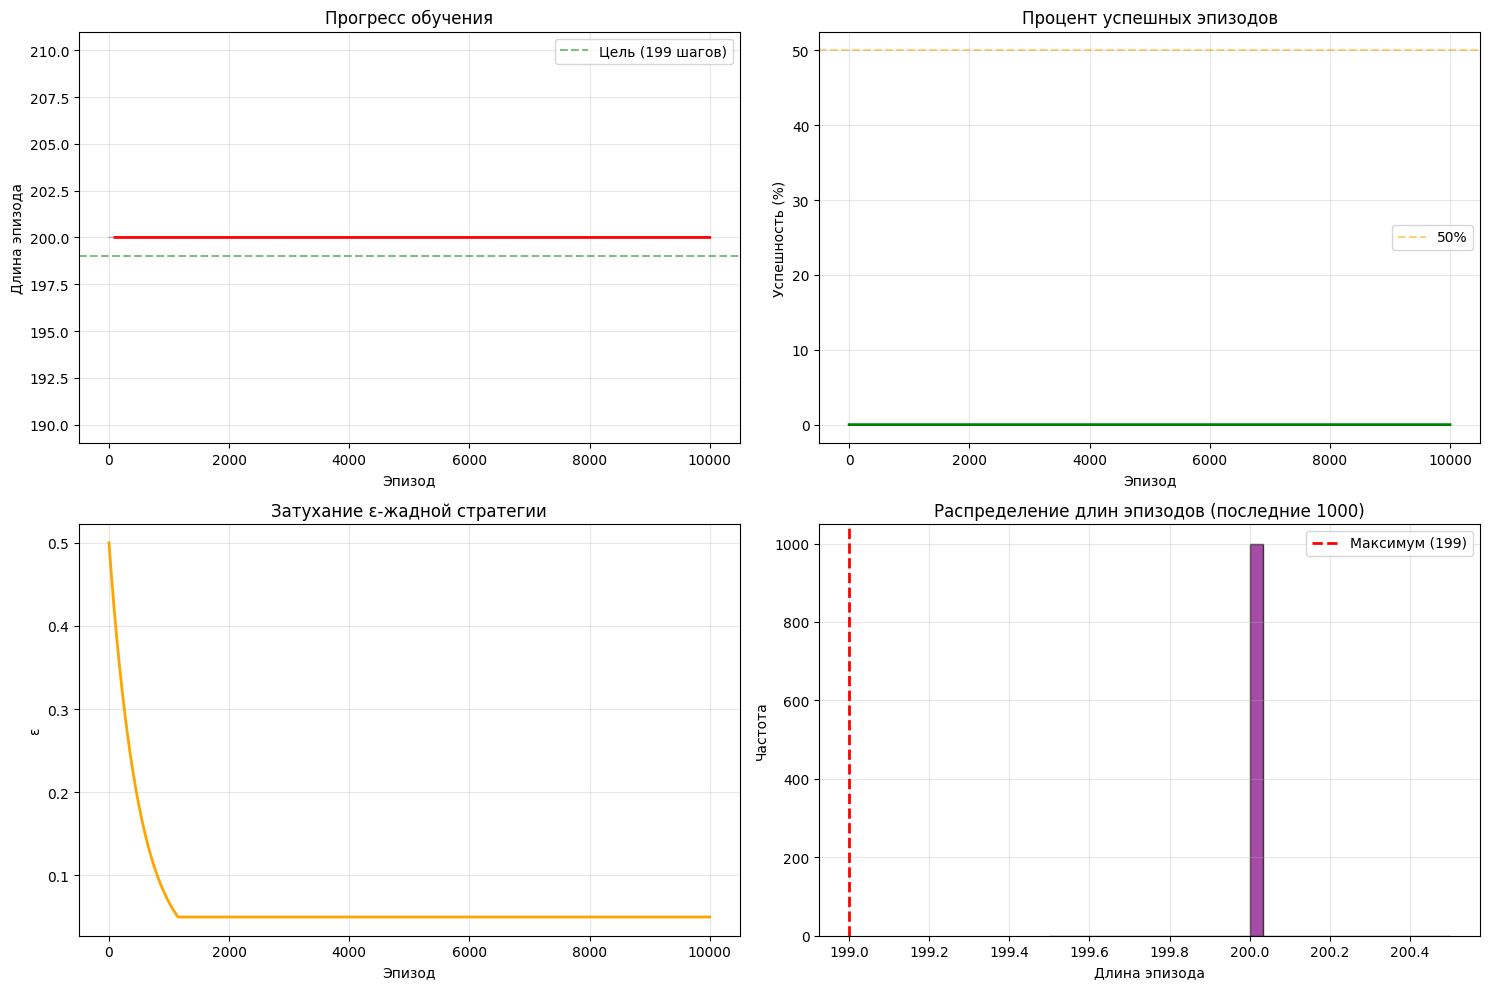


АНАЛИЗ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ

Статистика Q-значений:
  Минимум: -10.000
  Максимум: 179.519
  Среднее: 33.180
  Медиана: 12.879
  Стандартное отклонение: 41.917

Распределение оптимальных действий (всего 200 состояний):
  Влево (0): 73 (36.5%)
  Нейтрально (1): 50 (25.0%)
  Вправо (2): 77 (38.5%)

Итоговая статистика обучения:
  Средняя длина за последние 500 эпизодов: 200.0
  Успешность за последние 500 эпизодов: 0.0%
  Лучший результат: 200 шагов
  Худший результат: 200 шагов

СРАВНИТЕЛЬНЫЙ АНАЛИЗ СТРАТЕГИЙ

Влияние ε-жадной стратегии на обучение:
  ✓ Позволяет агенту исследовать новые действия
  ✓ Предотвращает застревание в локальных оптимумах
  ✓ Балансирует между exploration и exploitation
  ✓ Обеспечивает постепенное улучшение политики

Без ε-жадной стратегии (чисто жадная):
  ✗ Агент всегда выбирает лучшее действие по текущему мнению
  ✗ Не может открыть новые, более эффективные стратегии
  ✗ Быстро застревает в локальном минимуме
  ✗ Не способен найти оптимальную стратегию рас

In [57]:
print("="*60)
print("ДОМАШНЕЕ ЗАДАНИЕ: МОНТЕ-КАРЛО КОНТРОЛЬ С ε-ЖАДНОЙ СТРАТЕГИЕЙ")
print("="*60)

# Создание среды
env, n_buckets, state_bounds = create_discrete_env()

print(f"\nПараметры дискретизации:")
print(f"  Корзины: position={n_buckets[0]}, velocity={n_buckets[1]}")
print(f"  Всего состояний: {n_buckets[0] * n_buckets[1]}")

# Обучение на 10000 эпизодов
print("\n" + "="*50)
print("ЭТАП 1: ОБУЧЕНИЕ МЕТОДОМ МОНТЕ-КАРЛО (10000 эпизодов)")
print("="*50)

Q, policy, episode_lengths, success_episodes, epsilons = mc_control_epsilon_greedy(
    env=env,
    gamma=0.99,
    n_episode=10000,  # ИЗМЕНЕНО: теперь 10000 эпизодов
    epsilon_start=0.5,
    epsilon_decay=0.998,  # Более медленное затухание для 10000 эпизодов
    n_buckets=n_buckets,
    state_bounds=state_bounds
)

# Визуализация обучения
print("\n" + "="*50)
print("ЭТАП 2: ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ")
print("="*50)
visualize_learning(episode_lengths, success_episodes, epsilons)

# Анализ результатов
analyze_results(Q, policy, episode_lengths, success_episodes)

# Сохраняем важные переменные для демонстрации
from IPython import get_ipython
ipython = get_ipython()
ipython.run_line_magic('store', 'env')
ipython.run_line_magic('store', 'policy')
ipython.run_line_magic('store', 'n_buckets')
ipython.run_line_magic('store', 'state_bounds')

print("\n Модель обучена на 10000 эпизодов и сохранена для демонстрации!")

ДЕМОНСТРАЦИЯ РАБОТЫ (ОТДЕЛЬНО)

KeyboardInterrupt: 

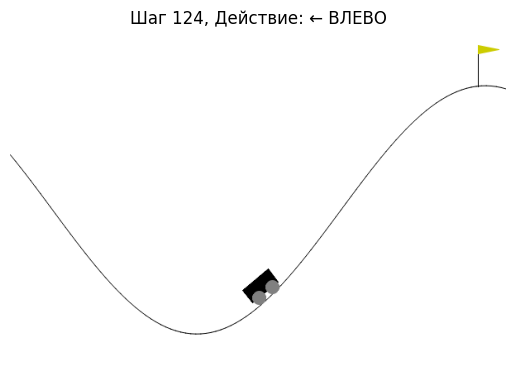

In [58]:
def demonstrate_agent(env, policy, n_buckets, state_bounds, n_episodes=3):
    """Демонстрирует работу обученного агента"""
    from IPython.display import clear_output, display as ip_display

    print("\n" + "="*50)
    print("ДЕМОНСТРАЦИЯ РАБОТЫ ОБУЧЕННОГО АГЕНТА")
    print("="*50)

    for episode in range(n_episodes):
        state_cont, _ = env.reset()
        state = discretize_state(state_cont, n_buckets, state_bounds)
        state_key = state_to_key(state)

        total_reward = 0
        steps = 0
        positions = []

        print(f"\nЭпизод {episode + 1}:")

        while True:
            # Используем жадную стратегию из policy
            if state_key in policy:
                action = policy[state_key]
            else:
                # Если состояние не встречалось, используем исследование
                action = random.randint(0, 2)

            # Визуализация
            img = env.render()
            plt.imshow(img)
            plt.axis('off')
            action_names = ["← ВЛЕВО", "○ НЕЙТРАЛЬНО", "→ ВПРАВО"]
            plt.title(f'Шаг {steps}, Действие: {action_names[action]}')
            clear_output(wait=True)
            ip_display(plt.gcf())

            next_state_cont, reward, done, truncated, _ = env.step(action)
            positions.append(next_state_cont[0])

            next_state = discretize_state(next_state_cont, n_buckets, state_bounds)
            next_state_key = state_to_key(next_state)

            state_key = next_state_key
            total_reward += reward
            steps += 1

            time.sleep(0.05)

            if done or truncated or steps >= 200:
                break

        # Оценка результата
        max_position = max(positions) if positions else -1.2
        success = max_position >= 0.5

        if success:
            print(f"  ✅ УСПЕХ! Достиг флага за {steps} шагов")
            print(f"  Максимальная высота: {max_position:.3f}")
        else:
            print(f"  ❌ НЕУДАЧА. Максимальная высота: {max_position:.3f}")

        time.sleep(1)

    env.close()
    print("\nДемонстрация завершена!")

# Восстанавливаем сохраненные переменные
try:
    from IPython import get_ipython
    ipython = get_ipython()
    ipython.run_line_magic('store', '-r env')
    ipython.run_line_magic('store', '-r policy')
    ipython.run_line_magic('store', '-r n_buckets')
    ipython.run_line_magic('store', '-r state_bounds')

    # Запускаем демонстрацию
    demonstrate_agent(env, policy, n_buckets, state_bounds, n_episodes=3)

except Exception as e:
    print("Ошибка: сначала выполните ячейку 3 с обучением!")
    print(f"Детали ошибки: {e}")